In [2]:
import pandas as pd
import pandana
#from pandana.loaders import osm

In [3]:
with pd.HDFStore("network.backup", "r") as store:
    display(store.keys())

['/edges', '/impedance_names', '/nodes', '/two_way']

In [4]:

with pd.HDFStore("network.backup", "r") as store:
    nodes = store.nodes
    edges = store.edges
    display(nodes.head())
    display(edges.head())

,x,y
id,,
30911432,12.008369,55.854892
30911433,12.007459,55.854768
30911438,12.001410,55.855358
30911440,11.999027,55.855389
30911444,11.995071,55.855122


,,from,to,distance
30911460,2317535578,30911460,2317535578,45.747006
2317535578,1085966713,2317535578,1085966713,27.317454
1085966713,6152193942,1085966713,6152193942,20.712985
30911438,1289275633,30911438,1289275633,38.543546
1289275633,1289275619,1289275633,1289275619,3.152245


In [5]:
network = pandana.Network.from_hdf5("network.backup")
network.precompute(3000)

Generating contraction hierarchies with 24 threads.
Setting CH node vector of size 1215
Setting CH edge vector of size 1622
Range graph removed 42 edges of 3244
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
 100% 

,x,y,price
0,11.992001,55.853243,12345
1,11.972115,55.854866,12345


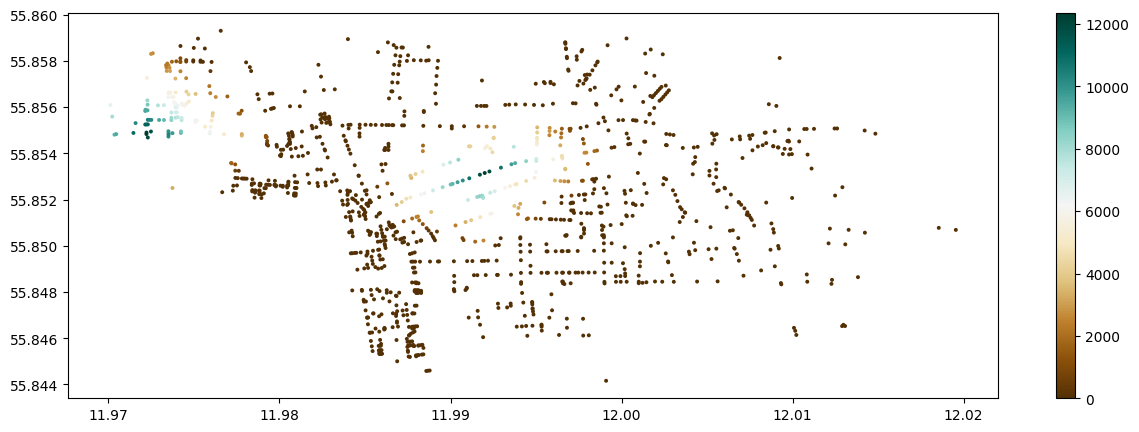

(<Figure size 1500x500 with 2 Axes>, <Axes: >)

In [6]:
df = pd.DataFrame.from_dict({
    "x": [11.992001, 11.972115,], 
    "y": [55.853243, 55.854866,],
    "price": [12345, 12345,],
})

display(df.head())

x, y = df.x,df.y
df["node_ids"] = network.get_node_ids(x, y)
network.set(df["node_ids"], variable=df.price, name="price")

aggregate = network.aggregate(500, type="sum", decay="linear", name="price")

bbox_jp = [55.845085, 11.970291, 55.858888, 12.014236]
network.plot(aggregate, bbox=bbox_jp,
         fig_kwargs={'figsize': [15, 5]},
         #cbar_kwargs={'suppress_ticks': False,
                      #'resolution': 'h', 'epsg': '26943'},
         plot_kwargs={'cmap': 'BrBG', 's': 8, 'edgecolor': 'none'})

In [7]:
aggregate.head()

id
30911432       0.000000
30911433       0.000000
30911438       0.000000
30911440       0.000000
30911444    3490.351339
dtype: float64

In [8]:
(bbox_jp[3] - bbox_jp[1]) / (bbox_jp[2] - bbox_jp[0])

3.183728175033802